#**CHAPTER 3.CONTEXT PACKING UNDER GOVERNANCE**
---

##REFERENCE

https://chatgpt.com/share/699b1be1-41b4-8012-8bf3-46ba65e5d67c

##0.CONTEXT

###0.1.OVERVIEW

**Board Briefing: What This Notebook Is Doing, Why It Matters, and What We Learned (Context Packing Under Governance)**

**Audience framing**
You are being asked to evaluate an AI-assisted workflow, not a “chatbot demo.” The notebook you are seeing is designed to behave like a controlled process that a finance organization can audit. It aims to turn model output into something closer to a governed internal memo pipeline: bounded inputs, explicit constraints, machine-checkable outputs, and evidence logs you can review after the fact. The headline is simple: we are demonstrating how a large language model can be used as a drafting component while the organization retains control of scope, inputs, and the rules of what the model is allowed to claim.

**The practical problem**
In finance, the cost of a false statement is not “oops.” It is committee confusion, mispricing risk, compliance exposure, and reputational damage. Generative models can draft quickly, but they also drift: they may invent missing details, blend external knowledge with internal packets, or produce output that looks plausible while being structurally unreviewable. In a board environment, reliability is not a vibe; it is an evidentiary standard. This notebook is addressing one of the most common failure modes: “context sprawl” and “context confusion.” When you give a model multiple documents, it will not automatically respect what should count as evidence. It may over-weight irrelevant content, ignore critical borrower-specific facts, or cite material outside the permitted packet.

**The core idea: Context Packing**
“Context packing” is the discipline of deciding what evidence is included vs excluded under a budget (token budget, attention budget, review budget). In a real credit memo process, we do this naturally: borrower package matters more than generic industry commentary; distractors should not enter the analysis. The model, however, will happily absorb whatever we feed it. Therefore the notebook treats the evidence set as a first-class governance object.

We create three documents:
1) a borrower-specific packet (high relevance),
2) a generic industry note (partial relevance),
3) a distractor (irrelevant).

We then run a controlled loop where the include/exclude set is explicit, logged, and updated by deterministic rules.

**What “governance-first” means here**
Governance-first means the model is not “trusted.” Instead, the process is trusted because it:
- defines a strict input boundary (exactly which docs count as evidence),
- requires a strict output contract (JSON schema with required fields),
- validates output deterministically (schema checks, boundary checks),
- fails closed (if controls fail, the pipeline escalates to HUMAN_REVIEW),
- produces an evidence bundle every run (manifests, logs, trace, and report),
- persists raw model responses for audit, so failures are inspectable.

In plain terms: the notebook is designed so that a reviewer can answer, after the fact:
- what evidence was provided,
- what prompt rules were applied,
- what the model returned,
- whether the output satisfied the contract,
- whether any governance gates failed,
- what risks were detected and what controls triggered escalation.

**The reasoning pipeline, step-by-step (as implemented)**
1) **Deterministic setup and reproducibility**
   The run is timestamped in UTC, seeded deterministically, and captured in a run manifest. This matters because governance requires reproducibility: when something goes wrong, we must be able to reproduce the failure mode.

2) **Bounded micro-case**
   The notebook constructs a synthetic borrower case and three evidence docs. Synthetic does not mean “toy.” It means we can demonstrate the mechanism without leaking sensitive real borrower data. The inputs are explicitly enumerated; the allowed doc IDs are fixed.

3) **Prompt lifecycle as an artifact**
   Each model call is not just “a call.” It is a prompt bundle with intent, version, constraints, and an output schema contract. We log prompt hashes (not raw secrets), store redacted prompts, and hash responses. This gives us an audit trail.

4) **Context packing loop**
   We start with a conservative include-set: borrower + industry. Distractor is excluded. We then ask the model to draft a memo that must:
   - use only included docs as facts,
   - separate facts vs assumptions vs open items,
   - label verification_status as “Not verified,”
   - output strict JSON only (not prose),
   - list referenced_doc_ids used (must be subset of include-set),
   - remain within output contract constraints.

5) **Strict parsing + schema enforcement**
   The model output must parse into JSON. The notebook does not “hope” it parses; it enforces it. It uses sentinel delimiters, code-fence stripping, and balanced extraction to recover valid JSON if the model wraps it. Then it validates the result against the JSON schema. If parsing or schema validation fails, the pipeline does not continue pretending. It triggers repair (one time) and otherwise fails closed.

6) **Mandatory repair (rebuild-from-included-docs)**
   This is a major governance improvement. Instead of trying to “fix” broken JSON, we discard the malformed output and re-run a repair prompt that rebuilds a compliant JSON object from the same bounded docs, at temperature 0.0, with stricter formatting constraints. This is not “agentic reasoning.” It is controlled remediation: a second attempt designed to correct formatting drift.

7) **Gates: boundary and materiality**
   Once we have a schema-valid output, we apply gates:
   - Boundary compliance: referenced_doc_ids must be subset of included docs; no mention of excluded doc IDs.
   - Material missing items: if open_items includes “MATERIAL:” entries, we escalate to HUMAN_REVIEW. This is deliberate: in finance, material diligence gaps are not optional.

8) **Prompt trace and risk log**
   The notebook records a structured prompt trace: what ran, what was included, whether repair ran, validation outcomes, next-action rationale. It also records a risk log with categories relevant to prompt workflows: schema_failure, evidence_boundary_violation, ambiguity_or_under_specification, assumption_leak, verbosity_or_format_drift, prompt_injection_or_override_attempt.

9) **Final report and readable report**
   The final_report.json is machine-checkable and suitable for programmatic review. The readable report is deliberately deterministic and artifact-grounded, so it does not invent explanations. This is crucial: an LLM-written narrative about LLM outputs can reintroduce hallucination at the reporting stage. We prevent that.

**What results mean in committee terms**
This notebook is not trying to “approve a loan.” It is demonstrating:
- how we can use LLMs for memo drafting while keeping controls,
- how we can ensure outputs are reviewable (structured, schema-valid),
- how we can detect and stop unsafe behavior (boundary violations, invented facts, format drift),
- how we can surface diligence gaps explicitly as open items,
- how we can produce audit artifacts that support oversight.

The direct value to a Board or Credit Committee is not that the model is “smart.” The value is that the pipeline is disciplined:
- It behaves consistently run-to-run.
- It produces evidence bundles that can be audited.
- It escalates rather than pretending certainty.
- It forces separation of facts vs assumptions vs unknowns.

**Why this is relevant for governance and risk**
AI adoption in finance fails when outputs are treated as answers rather than drafts under control. The model should be viewed like a junior analyst that drafts quickly but must be constrained by:
- a defined packet,
- a defined deliverable format,
- a controlled workflow,
- mandatory escalation conditions,
- and evidence logs.

This notebook operationalizes that posture. It is the foundation for scaling: once prompts are first-class artifacts and outputs are validated, we can add broader workflows (multi-pass critique, hardened prompts, regression testing) without losing reviewability.

**What this notebook is not doing**
It is important to state limits clearly:
- It is not verifying external truth. “Not verified” is explicit.
- It is not connecting to real financial systems or market feeds.
- It is not performing quantitative risk modeling or covenant sizing.
- It is not making autonomous decisions.
- It is not a substitute for human credit judgment.

**Bottom line**
This notebook demonstrates a controlled way to integrate LLM drafting into finance: explicit evidence boundaries, enforceable output contracts, deterministic validation, fail-closed escalation, and auditable artifacts. It is a governance mechanism that makes AI outputs defensible, not a claim that AI is infallible.

###0.2.ARCHITECTURAL EVOLUTION VS.PREVIOUS CHAPTERS

**Prompt Architecture**

**Chapter 1 — two static versions, one packet**
The prompt lifecycle is a fixed two-node sequence: v1 is a naïve instruction ("write a credit memo from this packet"), v2 is a contract prompt that adds role, objective, non-goals, refusal rules, boundary keys, and schema. There is one document — the synthetic case — and no concept of inclusion or exclusion. The schema is requested but not enforced at the output construction level.

**Chapter 2 — two static versions, output contract hardened**
Same two-node structure but the purpose of v2 shifts. The contrast is no longer "naïve vs contract" — it is "free-form prose vs schema-first JSON." v2 adds explicit character limits directly inside the prompt (`analysis ≤ 1200 chars`, `draft_output ≤ 900 chars`) to prevent token truncation from breaking the JSON object. Still one document. No sentinel delimiters.

**Chapter 3 — iterative versioned loop, multi-document evidence with include/exclude**
The prompt architecture becomes a loop. There is no v1/v2 comparison — every iteration uses a governed prompt from the start. The key structural additions are:

- **Three documents** (borrower packet, industry note, distractor) with explicit `include_ids` and `exclude_ids` passed into the prompt each iteration
- **Sentinel delimiters** (`<<<BEGIN_JSON>>>` / `<<<END_JSON>>>`) wrapping the expected output — a parsing control baked into the prompt itself
- **Two new required output fields**: `referenced_doc_ids` (the model must declare which docs it used) and `evidence_usage_justification` (the model must justify its evidence selection)
- **`questions_to_verify`** as a separate field from `open_items`
- A `select_evidence()` function that updates the include set on each iteration based on what the model actually referenced in the previous pass
- A **stability termination condition**: the loop stops when the include set is unchanged for `stability_required` consecutive iterations (default 2), or when `max_iterations` (default 6) is reached

---

**Control Architecture**

| | Ch1 | Ch2 | Ch3 |
|---|---|---|---|
| Gate path | Same 3 gates for both v1 and v2 | Separate gate per prompt version | Single gate path, applied every iteration |
| Gate A | Schema validity | Freeform: text marker check / Schema: JSON validity | Schema validity (pre-condition before any gate runs) |
| Gate B | Facts vs assumptions key check | Numerical boundary (numbers in output vs packet) | Doc ID subset check: `referenced_doc_ids` must be subset of `include_ids` |
| Gate C | Named marker scan ("bloomberg", "wacc") | Assumption leak | Doc ID mention scan (regex over analysis + draft text) + assumption leak |
| **New in Ch3** | — | — | **Material missing items**: if any `open_items` entry starts with `"MATERIAL:"` → HUMAN_REVIEW |
| Repair strategy | Send broken JSON back to model to fix | Discard broken output, rebuild from packet | Discard broken output, mandatory rebuild at `temperature=0.0` from included docs only |
| Repair trigger | Optional (`max_repair_attempts=1`) | On parse failure | **Always mandatory** if attempt 1 fails — not optional |
| Risk log | Appends every occurrence | Appends every occurrence | **Deduped** — same risk_id only recorded once per run |
| Fallback object | None — `parsed_output` is just `None` | None | Explicit `_fallback_output()` dict returned when all attempts fail — pipeline always has a valid object to report |
| Loop termination | Fixed: 2 calls | Fixed: 2 calls | Governed: stability condition OR max_iterations cap |

---

**The Conceptual Progression**

**Chapter 1** establishes that **the prompt is a contract**. Chapter 2 establishes that **the output must be machine-enforceable**. Chapter 3 asks a new question that neither earlier chapter addressed: **what counts as evidence, and who controls that decision?** The answer in Chapter 3 is that the evidence set is itself a governed artifact — tracked, hashed, updated by deterministic rules, and auditable iteration by iteration. The model no longer receives "the packet"; it receives a declared subset of available documents, and it must tell you which ones it actually used.

###0.3.STYLIZED COMPARISON ACROSS CHAPTERS

**The scenario:** A credit analyst submits a loan request for a mid-size manufacturer. The model is asked to produce a first-pass memo.

---

**Chapter 1 — You receive two memos and a pass/fail stamp**

The human gets a side-by-side comparison:

- *v1 output:* A fluent prose memo. Readable. Sounds confident. But the pipeline flags it immediately — Gate A fails because there is no machine-checkable structure separating facts from assumptions. Decision: **HUMAN_REVIEW**.
- *v2 output:* A JSON object with facts, assumptions, open items, and verification status. Gate A passes if the JSON is valid. Decision: **OK** or **HUMAN_REVIEW** depending on schema compliance.

What the human actually sees: two memos, a gate outcome table, a risk log, and a prompt trace showing why v2 was written differently from v1. The main value is the **comparison itself** — proof that contract prompts produce more governable output than naïve ones.

---

**Chapter 2 — You receive one governed memo with explicit disclosure fields**

No comparison this time. The human gets a single schema-first JSON output containing:

- 8 enumerated facts drawn strictly from the packet
- 4 explicitly declared assumptions (e.g. "pro forma leverage calculated as debt/EBITDA")
- 8 open items the model could not answer from available data
- Verification status: "Not verified"

Gates also check numerically — if the model invented a figure not present in the packet, it is flagged. The human receives a structured artifact they can challenge field by field, not a narrative they have to read and interpret. Decision: **HUMAN_REVIEW** pending resolution of open items.

---

**Chapter 3 — You receive an iterated memo with a full evidence trail**

The human gets everything above, plus something new: **a record of what evidence was included and excluded at each iteration**.

Iteration 1: borrower packet + industry note included, distractor excluded → model references only borrower packet → include set updates → iteration 2 stabilises → loop terminates.

The final output contains two additional fields: `referenced_doc_ids` (which documents the model actually used) and `evidence_usage_justification` (why). If any open item is prefixed `MATERIAL:` — meaning a critical diligence gap — the pipeline escalates automatically.

The human receives not just a memo but an **evidence selection log**: what was permitted, what was used, what was ignored, and why the loop stopped.

---

**In one line each:**
- Ch1: *Did the contract prompt produce better output than the naïve one?*
- Ch2: *Does the output meet the disclosure contract?*
- Ch3: *Did the model use the right evidence, and can we prove it?*

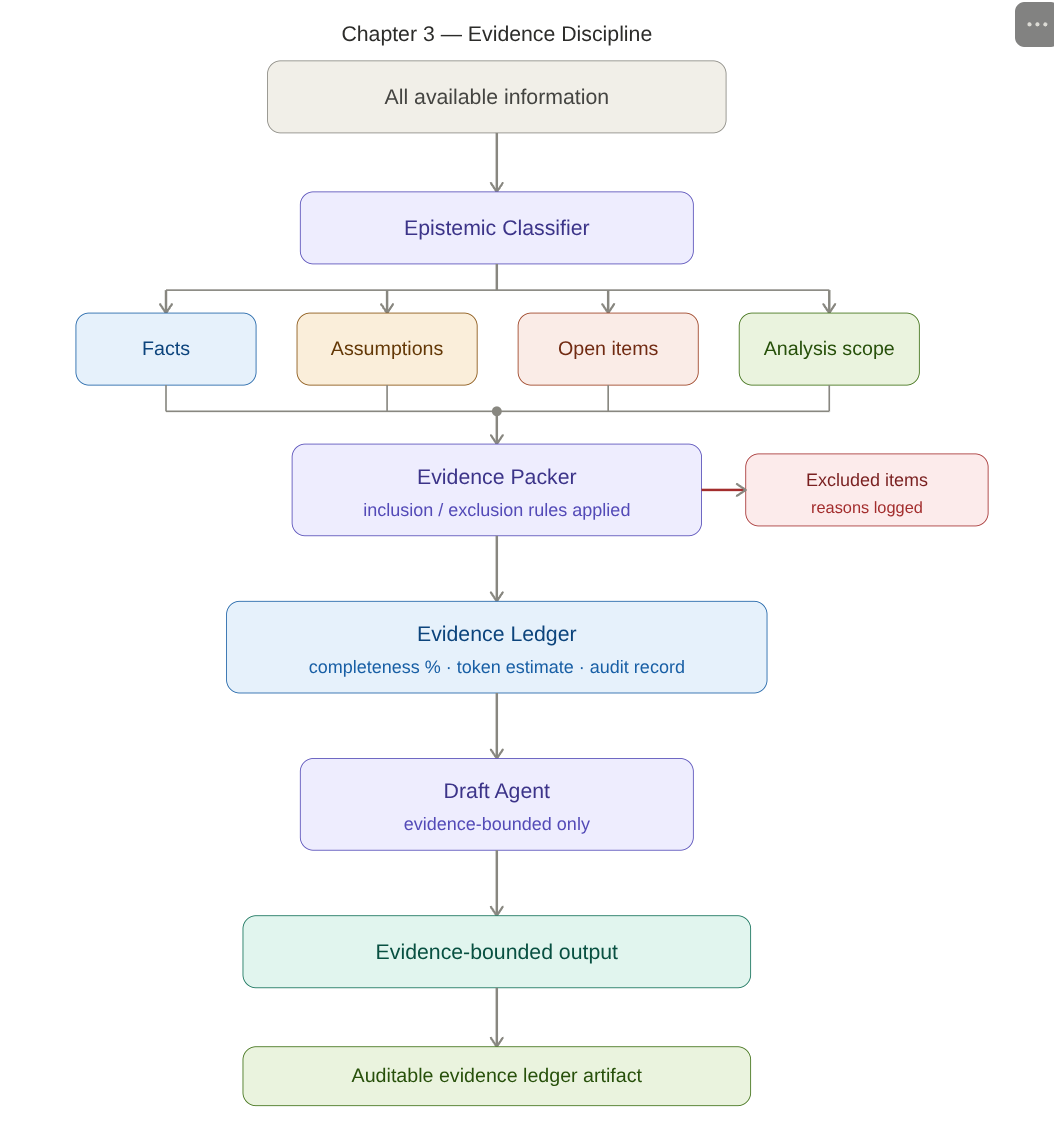

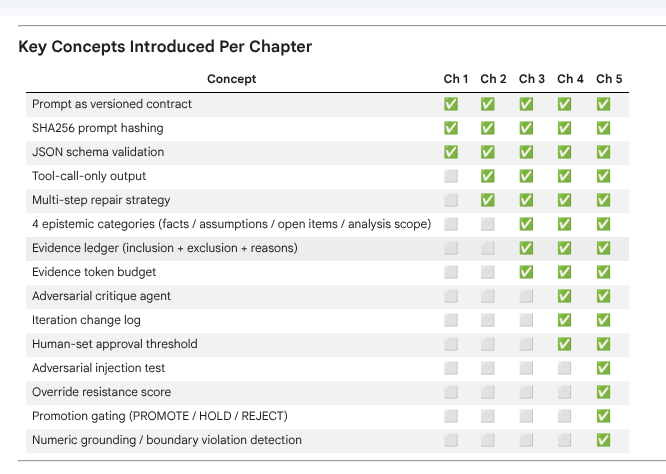

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 — Install, Imports, Determinism, and Directory Setup**

This cell prepares a clean execution environment in Google Colab and creates the minimal scaffolding required to run a controlled notebook end-to-end. The installation commands ensure that two key dependencies are available: the Anthropic SDK (to call the Claude Messages API) and jsonschema (to enforce a strict output contract). In a governance-first design, dependency control matters because an audit trail should reflect what code actually ran. When a committee asks “what changed between runs,” one important answer is “the software environment.” While Colab is not a locked-down production container, explicitly installing dependencies reduces uncertainty and helps reproducibility.

The imports define the notebook’s operational surface area: standard libraries for hashing, timestamps, file I/O, random seeding, zipping deliverables, and lightweight type hints. This is not cosmetic. The notebook is designed to produce artifacts that can be reviewed later (manifest, logs, trace, report), so file system and hashing capabilities are essential. The determinism configuration (setting PYTHONHASHSEED and random.seed) does not guarantee perfect determinism for model outputs, but it does guarantee determinism for everything we control: synthetic case generation, hashing, artifact naming, and any internal selection rules. This matters because we want to isolate model variability from workflow variability.

The directory setup creates an “artifacts” folder and a “deliverables” folder. In practical governance terms, these are the “evidence locker” and the “package to share.” You want all run outputs consistently stored in known paths, so reviewers can locate them without reading the entire notebook. The rest of the notebook assumes these directories exist; by creating them upfront, Cell 1 prevents failure modes later.

Overall, Cell 1 establishes an operating posture: this is not an interactive exploration notebook; it is a controlled run pipeline. Dependencies, paths, and deterministic settings are the first controls in that pipeline, and they are required to make subsequent controls meaningful.

In [ ]:
# Cell 1 — Install + imports + deterministic settings + directory setup
!pip -q install anthropic jsonschema

import os, re, json, time, random, hashlib, zipfile, pathlib, datetime
from typing import Any, Dict, List, Tuple

import jsonschema
from jsonschema import validate

##2.CONFIGURATION AND SCHEMAS

###2.1.OVERVIEW

**Cell 2 — Configuration, Output Contract, Helpers, and Risk Logging**

Cell 2 defines the governance contract that the model must obey, along with the supporting machinery to enforce it. The most important idea is that model output is not treated as “text,” but as a structured artifact governed by a schema. The output schema forces the memo into reviewable components: facts_provided, assumptions_introduced, open_items, questions_to_verify, analysis, draft_output, referenced_doc_ids, and verification_status. This structure makes the output auditable and makes downstream checks possible. Without this schema, you cannot reliably enforce “facts vs assumptions,” and you cannot compare outputs run-to-run.

This cell also defines time and hashing utilities. Timestamps are always UTC, which matters in governance settings because committees and auditors need an unambiguous clock. Hashing functions provide immutability anchors: we can hash a prompt, hash a response, and record those hashes in logs. If someone later asks whether an output was edited manually, hashes help detect tampering.

Redaction utilities are included because logs are meant to be shareable. Even in synthetic demos, you want the notebook’s design to be production-minded: do not write secrets to disk, do not log PII-like patterns if present, and default to minimum necessary content retention. The prompts_log.jsonl stores redacted prompts plus hashes; raw responses are stored separately for audit, but never secrets.

Risk logging is implemented as a first-class governance mechanism. The key improvement is deduplication: if the same control failure happens multiple times, we record it once with a stable risk_id. This keeps the risk log readable and makes board discussion clearer: one risk, one control, one status. The logger supports context fields so we can attach iteration/version without creating duplicates. In short: Cell 2 defines what “good” looks like (schema) and how we detect when “good” fails (risks), while ensuring we leave an audit trail the board can trust.

###2.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 2 — Config + schemas + helpers (hashing, redaction, JSON writing, validation) + DEDUPED RISK LOGGING

import os, re, json, time, random, hashlib, zipfile, pathlib, datetime
from typing import Any, Dict, List, Tuple

BASE_DIR = pathlib.Path(".").resolve()
ART_DIR = BASE_DIR / "artifacts"
DELIV_DIR = BASE_DIR / "deliverables"
ART_DIR.mkdir(parents=True, exist_ok=True)
DELIV_DIR.mkdir(parents=True, exist_ok=True)

def utc_now_iso() -> str:
    return datetime.datetime.now(datetime.timezone.utc).isoformat()

RUN_ID = hashlib.sha256(f"{utc_now_iso()}_{time.time_ns()}".encode("utf-8")).hexdigest()[:16]

# Determinism controls (best-effort inside notebook runtime)
os.environ["PYTHONHASHSEED"] = "1337"
random.seed(1337)

CONFIG: Dict[str, Any] = {
    "run_id": RUN_ID,
    "timestamp_utc": utc_now_iso(),
    "model": "claude-haiku-4-5-20251001",
    "temperature": 0.2,
    "max_tokens": 2500,          # raised from 1200
    "max_iterations": 6,
    "stability_required": 2,
    "hash_salt": "prompteng-finance-contextpacking-v1",
}

def sha256_text(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

def sha256_json(obj: Any) -> str:
    return sha256_text(json.dumps(obj, sort_keys=True, ensure_ascii=False, separators=(",", ":")))

def write_json(path: pathlib.Path, obj: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, sort_keys=True)

def append_jsonl(path: pathlib.Path, obj: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False, sort_keys=True) + "\n")

# Conservative redaction for prompts/logs (emails, phones, long digit strings)
EMAIL_RE = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
PHONE_RE = re.compile(r"(\+?\d[\d\-\s\(\)]{7,}\d)")
LONG_DIGIT_RE = re.compile(r"\b\d{10,}\b")

def redact_text(s: str) -> str:
    s = EMAIL_RE.sub("[REDACTED_EMAIL]", s)
    s = PHONE_RE.sub("[REDACTED_PHONE]", s)
    s = LONG_DIGIT_RE.sub("[REDACTED_LONG_NUMBER]", s)
    return s

# -------------------------
# DEDUPED RISK LOGGING
# -------------------------
RISK_LOG_PATH = ART_DIR / "risk_log.json"
RISK_ENTRIES: List[Dict[str, Any]] = []
_RISK_KEYS_SEEN: set = set()

def _risk_key(severity: str, category: str, description: str, control: str) -> str:
    s = (severity or "").strip().lower()
    c = (category or "").strip().lower()
    d = re.sub(r"\s+", " ", (description or "").strip())
    ctrl = re.sub(r"\s+", " ", (control or "").strip())
    return sha256_text(f"{RUN_ID}|{s}|{c}|{d}|{ctrl}")[:24]

def reset_risks() -> None:
    RISK_ENTRIES.clear()
    _RISK_KEYS_SEEN.clear()

def log_risk(severity: str, category: str, description: str, control: str, status: str, context: Dict[str, Any] = None) -> str:
    key = _risk_key(severity, category, description, control)
    if key in _RISK_KEYS_SEEN:
        return key
    _RISK_KEYS_SEEN.add(key)

    entry = {
        "risk_id": key,
        "timestamp_utc": utc_now_iso(),
        "severity": severity,
        "category": category,
        "description": description,
        "control": control,
        "status": status,
    }
    if isinstance(context, dict) and context:
        entry["context"] = context

    RISK_ENTRIES.append(entry)
    return key

# Output schema (strict)
OUTPUT_SCHEMA_ID = "finance_memo_context_packing_v1"
OUTPUT_SCHEMA: Dict[str, Any] = {
    "$id": OUTPUT_SCHEMA_ID,
    "type": "object",
    "additionalProperties": False,
    "required": [
        "facts_provided",
        "assumptions_introduced",
        "open_items",
        "questions_to_verify",
        "analysis",
        "draft_output",
        "verification_status",
        "referenced_doc_ids",
        "evidence_usage_justification",
    ],
    "properties": {
        "facts_provided": {"type": "array", "items": {"type": "string"}, "minItems": 1},
        "assumptions_introduced": {"type": "array", "items": {"type": "string"}},
        "open_items": {"type": "array", "items": {"type": "string"}},
        "questions_to_verify": {"type": "array", "items": {"type": "string"}},
        "analysis": {"type": "string", "minLength": 1},
        "draft_output": {"type": "string", "minLength": 1},
        "verification_status": {"type": "string", "enum": ["Not verified"]},
        "referenced_doc_ids": {"type": "array", "items": {"type": "string"}, "minItems": 1},
        "evidence_usage_justification": {"type": "string", "minLength": 1},
    },
}

# Final report schema (strict)
FINAL_REPORT_SCHEMA_ID = "final_report_context_packing_v1"
FINAL_REPORT_SCHEMA: Dict[str, Any] = {
    "$id": FINAL_REPORT_SCHEMA_ID,
    "type": "object",
    "additionalProperties": False,
    "required": [
        "run_id",
        "timestamp_utc",
        "chapter",
        "notebook",
        "decision",
        "verification_status",
        "final_include_set",
        "final_exclude_set",
        "iteration_history",
        "final_output",
        "open_items",
        "questions_to_verify",
        "risk_summary",
        "config",
    ],
    "properties": {
        "run_id": {"type": "string"},
        "timestamp_utc": {"type": "string"},
        "chapter": {"type": "string"},
        "notebook": {"type": "string"},
        "decision": {"type": "string", "enum": ["OK", "HUMAN_REVIEW"]},
        "verification_status": {"type": "string", "enum": ["Not verified"]},
        "final_include_set": {"type": "array", "items": {"type": "string"}},
        "final_exclude_set": {"type": "array", "items": {"type": "string"}},
        "iteration_history": {"type": "array", "items": {"type": "object"}},
        "final_output": {"type": "object"},
        "open_items": {"type": "array", "items": {"type": "string"}},
        "questions_to_verify": {"type": "array", "items": {"type": "string"}},
        "risk_summary": {"type": "object"},
        "config": {"type": "object"},
    },
}

PROMPTS_LOG_PATH = ART_DIR / "prompts_log.jsonl"
PROMPT_TRACE_PATH = ART_DIR / "prompt_trace.json"
FINAL_REPORT_PATH = ART_DIR / "final_report.json"
RUN_MANIFEST_PATH = ART_DIR / "run_manifest.json"

print("Initialized:", {"run_id": RUN_ID, "artifacts": str(ART_DIR), "deliverables": str(DELIV_DIR)})

Initialized: {'run_id': 'f0083c17323aefd5', 'artifacts': '/content/artifacts', 'deliverables': '/content/deliverables'}


##3.CASE GENERATOR

###3.1.OVERVIEW

**Cell 3 — Deterministic Synthetic Finance Micro-Case and Evidence Boundary**

Cell 3 constructs the bounded evidence packet that will be used for the demonstration. The borrower and documents are synthetic by design, which allows the team to demonstrate governance mechanisms without exposing sensitive borrower data. The cell creates three evidence documents with different relevance: a borrower packet containing specific loan request and financial figures, an industry note providing general context, and a distractor document unrelated to credit analysis. This is intentionally structured to test whether the pipeline can keep irrelevant context out.

The cell then defines the “input boundary”: a list of allowed doc IDs, a boundary identifier, and a hard rule that only included evidence docs may be used as factual sources. This boundary is treated as a governance object. It is hashed and carried forward so later artifacts can reference it. In practice, this is analogous to hashing a deal room packet or committee deck: you want to know exactly what content was inside the analysis boundary.

The deterministic aspect matters. Because we seed the random generator and hard-code the synthetic documents, the packet is consistent across runs. That means any differences in outputs can be attributed to prompt changes, model changes, or controlled parameter changes—not to shifting inputs. This is crucial for a board-level process: if you are going to evaluate whether the workflow is safe and useful, you must be able to run it again and see the same packet.

Finally, Cell 3 sets up the “evidence story” for the notebook: context packing is about inclusion/exclusion decisions under a boundary. If you cannot name the docs and the boundary, you cannot govern them. This cell turns “context” into a measurable, reviewable input to the pipeline.

###3.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 3 — Synthetic finance micro-case generator (deterministic) + input boundary definition + paths

import pathlib, json, random, os, re, hashlib, datetime, time
from typing import Any, Dict, List, Tuple

# --- Standard paths (align across notebooks) ---
ARTIFACTS_DIR = ART_DIR
DELIVERABLES_DIR = DELIV_DIR
RAW_RESPONSES_DIR = ARTIFACTS_DIR / "raw_responses"
RAW_RESPONSES_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    "run_manifest": ARTIFACTS_DIR / "run_manifest.json",
    "prompts_log": ARTIFACTS_DIR / "prompts_log.jsonl",
    "prompt_trace": ARTIFACTS_DIR / "prompt_trace.json",
    "risk_log": ARTIFACTS_DIR / "risk_log.json",
    "final_report": ARTIFACTS_DIR / "final_report.json",
    "readable_report": ARTIFACTS_DIR / "readable_report.md",
}

# Deterministic synthetic case
def make_synthetic_case() -> Dict[str, Any]:
    borrower = {
        "borrower_name": "Orchid Components LLC",
        "requested_facility": "USD 12,000,000 term loan",
        "purpose": "Equipment upgrade and working capital buffer",
        "tenor_months": 48,
        "security": "First lien on equipment; limited receivables pledge",
        "provided_financials": "Unaudited, management-prepared",
    }

    docs = {
        "DOC_BORROWER": {
            "title": "Borrower Packet (High Relevance)",
            "text": (
                "Orchid Components LLC requests a USD 12.0mm term loan, 48-month tenor, "
                "for equipment upgrades and working capital. Management reports FY-1 revenue "
                "USD 38.5mm and EBITDA USD 6.2mm, with FY-0 revenue USD 41.0mm and EBITDA USD 6.6mm. "
                "Key customers: three OEMs; top customer ~22% of revenue. "
                "Debt outstanding: USD 5.0mm revolver (undrawn at period end per management). "
                "Covenant preference: leverage covenant; monthly reporting. "
                "Risks noted by management: customer concentration and supply chain lead times."
            ),
        },
        "DOC_INDUSTRY": {
            "title": "Industry Note (Partial Relevance)",
            "text": (
                "The industrial components sector has seen margin pressure due to input cost volatility. "
                "Typical mid-market leverage for stable borrowers ranges 2.0x–4.0x EBITDA, but varies by cycle. "
                "Customer concentration is a common underwriting focus. "
                "Recent years have shown periodic logistics disruptions affecting lead times."
            ),
        },
        "DOC_DISTRACTOR": {
            "title": "Distractor Document (Irrelevant)",
            "text": (
                "This document discusses consumer streaming trends and subscription bundling strategies. "
                "It includes commentary on viewer engagement and content licensing."
            ),
        },
    }

    boundary = {
        "boundary_id": "CXPK_BOUNDARY_V1",
        "case_id": "SYN-CXPK-0003",
        "allowed_doc_ids": sorted(list(docs.keys())),
        "hard_rule": "Only INCLUDED_EVIDENCE_DOCS may be used as facts.",
    }

    return {
        "case_id": boundary["case_id"],
        "timestamp_utc": utc_now_iso(),
        "borrower": borrower,
        "docs": docs,
        "input_boundary": boundary,
    }

CASE = make_synthetic_case()
BOUNDARY_SHA256 = sha256_json(CASE["input_boundary"])
print("Cell 3 ready:", {"case_id": CASE["case_id"], "allowed_doc_ids": CASE["input_boundary"]["allowed_doc_ids"]})

Cell 3 ready: {'case_id': 'SYN-CXPK-0003', 'allowed_doc_ids': ['DOC_BORROWER', 'DOC_DISTRACTOR', 'DOC_INDUSTRY']}


##4.LLM  WRAPPER

###4.1.OVERVIEW

**Cell 4 — LLM Wrapper, Prompt Logging, and Raw Response Persistence**

Cell 4 is the operational interface between governance logic and the Claude model. This is where we enforce “controlled invocation” rather than ad hoc prompting. The key controls implemented here are: secret handling, bounded sampling, logging, and raw response persistence.

First, the Anthropic API key is retrieved from Colab Secrets via google.colab.userdata.get, which keeps secrets out of the notebook text and out of logs. If the secret is missing, the cell fails fast. That is a governance posture: we do not run in a misconfigured state that could lead to partial artifacts or ambiguous results.

Second, the model call is bounded: temperature is capped (to reduce variability) and max_tokens is capped (to reduce truncation risk and cost). Those parameters are logged so reviewers can see the operating configuration.

Third, every call produces a prompt event: we hash the full prompt text (system + user) for integrity, store a redacted version for safe review, hash the response for integrity, and record timestamps. This creates an audit trail suitable for internal controls.

Fourth, raw response persistence is crucial. Parsing failures are the dominant operational risk for schema-first workflows. When parsing fails, you must be able to inspect what the model actually returned. Raw response files are stored under artifacts/raw_responses with deterministic names that include run_id, prompt_id, version, and intent. This makes troubleshooting board-grade: you can point to a file and say, “here is the exact output that caused the control to fail.”

In summary, Cell 4 transforms “model call” into a governed event with traceability, bounded behavior, and stored evidence. Without this cell, you cannot reliably claim the pipeline is auditable.

###4.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 4 — LLM client wrapper (Anthropic) + prompt logging (redacted + hashes) + RAW RESPONSE PERSISTENCE (AUDIT)

from google.colab import userdata
from anthropic import Anthropic

MODEL_NAME = CONFIG["model"]
TEMPERATURE = float(CONFIG["temperature"])
MAX_TOKENS = int(CONFIG["max_tokens"])

API_KEY = userdata.get("ANTHROPIC_API_KEY")
if not API_KEY or not isinstance(API_KEY, str) or len(API_KEY.strip()) < 10:
    log_risk(
        severity="high",
        category="instruction_conflict",
        description="Missing ANTHROPIC_API_KEY in Colab Secrets.",
        control="Require ANTHROPIC_API_KEY via google.colab.userdata.get; fail closed.",
        status="open",
    )
    raise RuntimeError("Missing ANTHROPIC_API_KEY in Colab Secrets.")

client = Anthropic(api_key=API_KEY.strip())

def make_prompt_id(prompt_text: str) -> str:
    return sha256_text(prompt_text)[:16]

def log_prompt_event(event: Dict[str, Any]) -> None:
    append_jsonl(PATHS["prompts_log"], event)

def call_claude(system_text: str, user_text: str, temperature: float, max_tokens: int) -> str:
    temperature = float(max(0.0, min(0.4, temperature)))
    max_tokens = int(max(200, min(1600, max_tokens)))

    msg = client.messages.create(
        model=MODEL_NAME,
        max_tokens=max_tokens,
        temperature=temperature,
        system=system_text,
        messages=[{"role": "user", "content": user_text}],
    )

    out_parts = []
    for block in msg.content:
        if getattr(block, "type", None) == "text":
            out_parts.append(block.text)
    return "\n".join(out_parts).strip()

def run_llm(prompt_bundle: Dict[str, Any]) -> Dict[str, Any]:
    system_text = prompt_bundle["prompt_components"]["system_policy"]
    user_text = prompt_bundle["prompt_components"]["user_task_spec"]

    raw_prompt_text = f"SYSTEM:\n{system_text}\n\nUSER:\n{user_text}"
    prompt_id = prompt_bundle["prompt_id"]
    prompt_sha = sha256_text(raw_prompt_text)
    redacted = redact_text(raw_prompt_text)

    started = utc_now_iso()
    response_text = call_claude(
        system_text=system_text,
        user_text=user_text,
        temperature=float(prompt_bundle.get("sampling", {}).get("temperature", TEMPERATURE)),
        max_tokens=int(prompt_bundle.get("sampling", {}).get("max_tokens", MAX_TOKENS)),
    )
    finished = utc_now_iso()
    response_sha = sha256_text(response_text)

    RAW_RESPONSES_DIR.mkdir(parents=True, exist_ok=True)
    raw_path = RAW_RESPONSES_DIR / f"{RUN_ID}__{prompt_id}__{prompt_bundle['prompt_version']}__{prompt_bundle['prompt_intent']}.txt"
    with open(raw_path, "w", encoding="utf-8") as f:
        f.write(response_text)

    log_prompt_event({
        "run_id": RUN_ID,
        "timestamp_utc": finished,
        "prompt_id": prompt_id,
        "prompt_version": prompt_bundle["prompt_version"],
        "prompt_intent": prompt_bundle["prompt_intent"],
        "output_schema_id": prompt_bundle.get("output_schema_id"),
        "prompt_sha256": prompt_sha,
        "response_sha256": response_sha,
        "redacted_prompt_text": redacted[:4000],
        "sampling": prompt_bundle.get("sampling", {"temperature": TEMPERATURE, "max_tokens": MAX_TOKENS}),
        "timing": {"started_utc": started, "finished_utc": finished},
        "raw_response_path": str(raw_path),
    })

    return {
        "prompt_id": prompt_id,
        "prompt_version": prompt_bundle["prompt_version"],
        "prompt_intent": prompt_bundle["prompt_intent"],
        "output_schema_id": prompt_bundle.get("output_schema_id"),
        "response_text": response_text,
        "prompt_sha256": prompt_sha,
        "response_sha256": response_sha,
        "timestamp_utc": finished,
        "raw_response_path": str(raw_path),
    }

print("Cell 4 ready:", {"model": MODEL_NAME, "temperature": TEMPERATURE, "max_tokens": MAX_TOKENS, "raw_dir": str(RAW_RESPONSES_DIR)})

Cell 4 ready: {'model': 'claude-haiku-4-5-20251001', 'temperature': 0.2, 'max_tokens': 2500, 'raw_dir': '/content/artifacts/raw_responses'}


##5.CONTEXT PACKING ENGINE

###5.1.OVERVIEW

**Cell 5 — Context Packing Engine (Selection, Prompting, Parsing, Repair, Gates, Trace Nodes)**

Cell 5 is the heart of the notebook. It operationalizes context packing as a governed loop: choose what evidence is included, prompt the model under a strict boundary, parse and validate the output, repair once if needed, apply gates, and record a trace node.

The loop starts with a conservative include-set: borrower + industry, excluding the distractor. This aligns with how a credit process prioritizes borrower-specific information and uses industry context selectively. The model is asked to draft a memo that must be strict JSON, must separate facts/assumptions/open items, must label verification_status as Not verified, and must list referenced_doc_ids used. These requirements are not “style.” They are controls that make the output reviewable and testable.

Parsing is handled as a layered control: sentinel delimiters to isolate the intended JSON, code-fence stripping to handle formatting wrappers, and largest-balanced-object extraction to recover the best candidate JSON object even if extra content is present. This solves common real-world failures: preambles, epilogues, triple-backtick fences, and multiple JSON objects.

Repair is mandatory when attempt 1 fails. Importantly, repair is not “fix the broken JSON.” Repair is “rebuild a compliant JSON object from the bounded docs.” This avoids brittle, heuristic JSON repair and instead uses the model as a generator under stricter constraints (temperature 0.0). Both attempt 1 and repair outputs are persisted as raw responses for audit.

Gates are applied only after schema validity is confirmed and only when the output is not a fallback artifact. This prevents false risk logs based on invalid or placeholder output. When gates fail (boundary violation, material missing items), the pipeline escalates to HUMAN_REVIEW and stops.

Finally, a prompt trace node is recorded with raw paths, repair status, parse diagnostics, include/exclude sets, and next_action rationale. This trace is the committee-friendly “flight recorder” of the run.

This cell is the mechanism the board should focus on: it is where AI becomes a controlled drafting component rather than an uncontrolled generator.

###5.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 5 — Context Packing Engine (FINAL PATCH: code-fence stripping + largest-balanced JSON + correct fallback gating + mandatory repair + raw paths)

import json
import jsonschema
from typing import Any, Dict, List, Tuple

JSON_SENTINELS = {"begin": "<<<BEGIN_JSON>>>", "end": "<<<END_JSON>>>"}

def _strip_fences(x: str) -> str:
    x2 = (x or "").strip()
    # Remove leading/trailing code fences ``` or ```json
    if x2.startswith("```"):
        nl = x2.find("\n")
        if nl != -1:
            x2 = x2[nl + 1 :]
        if x2.rstrip().endswith("```"):
            x2 = x2.rstrip()[:-3]
    return x2.strip()

def _extract_balanced_json_blocks(s: str) -> List[str]:
    # Extract all top-level balanced {...} blocks, respecting strings/escapes.
    blocks = []
    if not isinstance(s, str) or not s:
        return blocks
    start = None
    depth = 0
    in_str = False
    esc = False
    for i, ch in enumerate(s):
        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
            continue
        else:
            if ch == '"':
                in_str = True
                continue
            if ch == "{":
                if depth == 0:
                    start = i
                depth += 1
            elif ch == "}":
                if depth > 0:
                    depth -= 1
                    if depth == 0 and start is not None:
                        blocks.append(s[start : i + 1].strip())
                        start = None
    return blocks

def _parse_json_strict(raw_text: str) -> Tuple[bool, Any, Dict[str, Any]]:
    diag = {"raw_len": len(raw_text or ""), "strategy": None, "error": None, "extracted_len": None}
    if not isinstance(raw_text, str) or not raw_text.strip():
        diag["strategy"] = "empty"
        diag["error"] = "Empty response."
        return False, None, diag

    t = _strip_fences(raw_text)
    b, e = JSON_SENTINELS["begin"], JSON_SENTINELS["end"]

    # Stage 0: sentinel slice
    if b in t and e in t:
        inner = t.split(b, 1)[1].split(e, 1)[0].strip()
        inner = _strip_fences(inner)
        diag["strategy"] = "sentinel_slice"
        diag["extracted_len"] = len(inner)
        try:
            return True, json.loads(inner), diag
        except Exception as ex:
            diag["strategy"] = "sentinel_slice_failed"
            diag["error"] = f"{type(ex).__name__}: {str(ex)[:220]}"

    # Stage 1: strict full string (after fence stripping)
    t2 = t.strip()
    if t2.startswith("{") and t2.endswith("}"):
        diag["strategy"] = "strict_full"
        diag["extracted_len"] = len(t2)
        try:
            return True, json.loads(t2), diag
        except Exception as ex:
            diag["strategy"] = "strict_full_failed"
            diag["error"] = f"{type(ex).__name__}: {str(ex)[:220]}"

    # Stage 2: balanced extraction (try largest block first)
    blocks = _extract_balanced_json_blocks(t2)
    if not blocks:
        diag["strategy"] = "balanced_extract_failed"
        diag["error"] = "No balanced JSON object found."
        return False, None, diag

    blocks = sorted(blocks, key=lambda x: len(x), reverse=True)
    for idx, candidate in enumerate(blocks[:3]):  # bounded attempts
        cand = _strip_fences(candidate)
        diag_try = dict(diag)
        diag_try["strategy"] = f"balanced_extract_largest_{idx}"
        diag_try["extracted_len"] = len(cand)
        try:
            return True, json.loads(cand), diag_try
        except Exception as ex:
            diag_try["error"] = f"{type(ex).__name__}: {str(ex)[:220]}"
            diag = diag_try

    diag["strategy"] = "balanced_extract_parse_failed"
    if diag.get("error") is None:
        diag["error"] = "Balanced extraction parse failed."
    return False, None, diag

def validate_schema_or_fail(output_obj: Any) -> Tuple[bool, str]:
    try:
        jsonschema.validate(instance=output_obj, schema=OUTPUT_SCHEMA)
        return True, "schema_ok"
    except Exception as e:
        return False, f"{type(e).__name__}: {str(e)[:260]}"

def _included_docs_payload(case: Dict[str, Any], include_ids: List[str]) -> Dict[str, Any]:
    docs = case["docs"]
    return {doc_id: {"title": docs[doc_id]["title"], "text": docs[doc_id]["text"]} for doc_id in include_ids}

def select_evidence(state: Dict[str, Any], case: Dict[str, Any]) -> Dict[str, Any]:
    if not state.get("include_set"):
        state["include_set"] = ["DOC_BORROWER", "DOC_INDUSTRY"]
        state["exclude_set"] = [d for d in case["input_boundary"]["allowed_doc_ids"] if d not in state["include_set"]]
        state["change_rationale"] = "Initialize conservative include-set: borrower + industry; exclude distractor."
        return state

    referenced = sorted(list(set(state.get("last_referenced_doc_ids", []))))
    allowed = case["input_boundary"]["allowed_doc_ids"]
    new_include = [d for d in allowed if d in referenced] if referenced else state["include_set"]
    if not new_include:
        new_include = state["include_set"][:]
    new_exclude = [d for d in allowed if d not in new_include]

    state["change_rationale"] = "No change: include-set stable." if new_include == state["include_set"] else f"Update include-set to referenced_doc_ids: {referenced}"
    state["include_set"] = new_include
    state["exclude_set"] = new_exclude
    return state

def build_prompt_with_boundary(case: Dict[str, Any], include_ids: List[str], exclude_ids: List[str], version: str) -> Dict[str, Any]:
    system_policy = (
        "You are a governance-first finance assistant producing board-ready, control-grade outputs.\n"
        "STRICT EVIDENCE BOUNDARY: use ONLY INCLUDED_EVIDENCE_DOCS as factual sources.\n"
        "Never invent facts, numbers, market data, ratings, prices, or sources.\n"
        "If unknown, list it in open_items and questions_to_verify.\n"
        "Output must be ONE JSON object matching OUTPUT_SCHEMA exactly (no extra keys).\n"
        f"Output must appear only between {JSON_SENTINELS['begin']} and {JSON_SENTINELS['end']}.\n"
        "No markdown, no code fences, no preamble, no epilogue.\n"
        "If you cannot comply, output '{}' ONLY between sentinels.\n"
    )

    user_task = (
        "TASK: Create a first-pass credit-style memo for committee review using ONLY INCLUDED_EVIDENCE_DOCS.\n"
        "HARD CONSTRAINTS:\n"
        f"- Only INCLUDED_DOC_IDS: {include_ids}\n"
        f"- Do NOT mention EXCLUDED_DOC_IDS: {exclude_ids}\n"
        "- Do NOT invent facts or numbers.\n"
        "- verification_status must be exactly: \"Not verified\".\n"
        "- referenced_doc_ids must be a subset of INCLUDED_DOC_IDS and list only what you used.\n"
        "- If missing info is MATERIAL, prefix open_items entry with 'MATERIAL:'.\n"
        "- Output ONE JSON object only.\n"
        f"- Output must be ONLY between sentinels:\n  {JSON_SENTINELS['begin']}\n  {JSON_SENTINELS['end']}\n"
        "- JSON must start with '{' and end with '}'.\n"
        "OUTPUT LENGTH LIMITS (required to prevent truncation):\n"   # ← added
        "  * analysis <= 1200 characters\n"                           # ← added
        "  * draft_output <= 900 characters\n"                        # ← added
        "  * evidence_usage_justification <= 400 characters\n"        # ← added
        "  * list fields: short bullet strings only\n"                # ← added
        "  * If running long, shorten draft_output first. DO NOT truncate the JSON.\n\n"  # ← added
        f"{JSON_SENTINELS['begin']}\n"
        "PUT THE JSON OBJECT HERE.\n"
        f"{JSON_SENTINELS['end']}\n\n"
        f"OUTPUT_SCHEMA(JSONSCHEMA):\n{json.dumps(OUTPUT_SCHEMA, ensure_ascii=False, indent=2)}\n\n"
        f"INCLUDED_EVIDENCE_DOCS(JSON):\n{json.dumps(_included_docs_payload(case, include_ids), ensure_ascii=False, indent=2)}\n"
    )

    raw_prompt_text = f"SYSTEM:\n{system_policy}\n\nUSER:\n{user_task}"
    pid = make_prompt_id(raw_prompt_text)

    return {
        "prompt_id": pid,
        "prompt_version": version,
        "prompt_intent": "draft_with_context_boundary",
        "output_schema_id": OUTPUT_SCHEMA_ID,
        "sampling": {"temperature": TEMPERATURE, "max_tokens": MAX_TOKENS},
        "prompt_components": {
            "system_policy": system_policy,
            "developer_constraints": [],
            "user_task_spec": user_task,
            "input_boundary": {
                "boundary_id": CASE["input_boundary"]["boundary_id"],
                "boundary_sha256": BOUNDARY_SHA256,
                "included_doc_ids": include_ids,
                "excluded_doc_ids": exclude_ids,
            },
            "output_schema": OUTPUT_SCHEMA,
            "stop_rules": [
                "Return JSON only between sentinels.",
                "No markdown / no code fences.",
                "No extra keys; follow schema exactly.",
                "No invented facts; unknowns go to open_items/questions_to_verify.",
                "Never mention excluded docs.",
            ],
        },
    }

def build_repair_prompt(case: Dict[str, Any], include_ids: List[str], exclude_ids: List[str]) -> Dict[str, Any]:
    system_policy = (
        "You are a strict JSON generator under governance controls.\n"
        "Return ONLY one valid JSON object matching the provided JSON Schema exactly.\n"
        "No markdown, no code fences, no commentary.\n"
        "Do NOT invent facts or numbers. Unknowns go to open_items and questions_to_verify.\n"
        f"Output must appear only between {JSON_SENTINELS['begin']} and {JSON_SENTINELS['end']}.\n"
        "Keep analysis and draft_output concise to avoid truncation.\n"
    )

    user_task = (
        "REPAIR TASK: Generate a schema-compliant JSON memo from the bounded inputs.\n"
        "HARD RULES:\n"
        f"- Only INCLUDED_DOC_IDS: {include_ids}\n"
        f"- Never mention EXCLUDED_DOC_IDS: {exclude_ids}\n"
        "- verification_status must be \"Not verified\".\n"
        "- referenced_doc_ids must be subset of INCLUDED_DOC_IDS.\n"
        "- If something is missing, put it in open_items (prefix 'MATERIAL:' when appropriate).\n"
        "- Output ONE JSON object only.\n"
        f"- JSON must start with '{{' and end with '}}'.\n\n"
        f"{JSON_SENTINELS['begin']}\n"
        "PUT THE JSON OBJECT HERE.\n"
        f"{JSON_SENTINELS['end']}\n\n"
        f"OUTPUT_SCHEMA(JSONSCHEMA):\n{json.dumps(OUTPUT_SCHEMA, ensure_ascii=False, indent=2)}\n\n"
        f"INCLUDED_EVIDENCE_DOCS(JSON):\n{json.dumps(_included_docs_payload(case, include_ids), ensure_ascii=False, indent=2)}\n"
    )

    raw_prompt_text = f"SYSTEM:\n{system_policy}\n\nUSER:\n{user_task}"
    pid = make_prompt_id(raw_prompt_text)

    return {
        "prompt_id": pid,
        "prompt_version": "repair_v1",
        "prompt_intent": "repair_rebuild_from_included_docs",
        "output_schema_id": OUTPUT_SCHEMA_ID,
        "sampling": {"temperature": 0.0, "max_tokens": min(1400, MAX_TOKENS)},
        "prompt_components": {
            "system_policy": system_policy,
            "developer_constraints": [],
            "user_task_spec": user_task,
            "input_boundary": {
                "boundary_id": CASE["input_boundary"]["boundary_id"],
                "boundary_sha256": BOUNDARY_SHA256,
                "included_doc_ids": include_ids,
                "excluded_doc_ids": exclude_ids,
            },
            "output_schema": OUTPUT_SCHEMA,
            "stop_rules": [
                "Return JSON only between sentinels.",
                "No markdown / no code fences.",
                "No extra keys; follow schema exactly.",
                "No invented facts; unknowns go to open_items/questions_to_verify.",
                "Never mention excluded docs.",
            ],
        },
    }

def _fallback_output() -> Dict[str, Any]:
    return {
        "__fallback__": True,
        "facts_provided": ["No valid governed output produced."],
        "assumptions_introduced": [],
        "open_items": ["MATERIAL: No valid governed output; requires human review."],
        "questions_to_verify": ["Inspect artifacts/raw_responses and prompt_trace; rerun after fixes."],
        "analysis": "Control failure prevented generating a valid governed memo.",
        "draft_output": "HUMAN_REVIEW required.",
        "verification_status": "Not verified",
        "referenced_doc_ids": [],
        "evidence_usage_justification": "N/A due to control failure.",
    }

def run_context_loop(case: Dict[str, Any]) -> Tuple[Dict[str, Any], Dict[str, Any], str]:
    state: Dict[str, Any] = {
        "iteration": 1,
        "include_set": [],
        "exclude_set": [],
        "last_referenced_doc_ids": [],
        "stable_count": 0,
        "last_include_sig": None,
        "decision": "OK",
    }

    nodes: List[Dict[str, Any]] = []
    final_output: Dict[str, Any] = {}

    fallback = _fallback_output()

    while True:
        if state["iteration"] > int(CONFIG["max_iterations"]):
            log_risk(
                severity="high",
                category="verbosity_or_format_drift",
                description=f"Max iterations exceeded ({CONFIG['max_iterations']}).",
                control="Gate A: max_iterations; fail closed.",
                status="open",
                context={"iteration": state["iteration"]},
            )
            state["decision"] = "HUMAN_REVIEW"
            final_output = fallback
            break

        state = select_evidence(state, case)
        include_ids = state["include_set"][:]
        exclude_ids = state["exclude_set"][:]

        include_sig = sha256_text("|".join(include_ids))
        if state["last_include_sig"] == include_sig:
            state["stable_count"] += 1
        else:
            state["stable_count"] = 1
        state["last_include_sig"] = include_sig

        version = f"v{state['iteration']}"
        prompt_bundle = build_prompt_with_boundary(case, include_ids, exclude_ids, version)

        # Attempt 1: draft call
        resp1 = run_llm(prompt_bundle)
        if not resp1.get("raw_response_path"):
            raise RuntimeError("Draft call did not persist raw response (raw_response_path missing).")

        ok1, obj1, diag1 = _parse_json_strict(resp1["response_text"])
        schema_ok1, schema_msg1 = (False, "parse_failed")
        if ok1 and isinstance(obj1, dict):
            schema_ok1, schema_msg1 = validate_schema_or_fail(obj1)
            ok1 = ok1 and schema_ok1

        used_repair = False
        resp2 = None
        obj_final = None
        parse_diag_final: Dict[str, Any] = {"attempt1": diag1, "repair_used": False, "schema_msg1": schema_msg1}
        gate_flags: List[str] = []

        # Attempt 2: repair (mandatory if attempt1 fails)
        if ok1 and isinstance(obj1, dict):
            obj_final = obj1
        else:
            used_repair = True
            log_risk(
                severity="high",
                category="schema_failure",
                description=f"Attempt1 failed (parse/schema). Trigger repair rebuild. parse_diag={diag1} schema_msg={schema_msg1}",
                control="Repair rebuild-from-included-docs, then re-parse and validate.",
                status="open",
                context={"iteration": state["iteration"], "version": version},
            )
            repair_bundle = build_repair_prompt(case, include_ids, exclude_ids)
            resp2 = run_llm(repair_bundle)
            if not resp2.get("raw_response_path"):
                raise RuntimeError("Repair call did not persist raw response (raw_response_path missing).")

            ok2, obj2, diag2 = _parse_json_strict(resp2["response_text"])
            parse_diag_final = {"attempt1": diag1, "attempt2": diag2, "repair_used": True, "schema_msg1": schema_msg1}
            if ok2 and isinstance(obj2, dict):
                schema_ok2, schema_msg2 = validate_schema_or_fail(obj2)
                parse_diag_final["schema_msg2"] = schema_msg2
                if schema_ok2:
                    obj_final = obj2
                else:
                    log_risk(
                        severity="high",
                        category="schema_failure",
                        description=f"Repair schema failed: {schema_msg2}",
                        control="Fail closed after repair schema failure.",
                        status="open",
                        context={"iteration": state["iteration"], "version": version},
                    )
                    state["decision"] = "HUMAN_REVIEW"
            else:
                log_risk(
                    severity="high",
                    category="schema_failure",
                    description=f"Repair parse failed: {diag2}",
                    control="Fail closed after repair parse failure.",
                    status="open",
                    context={"iteration": state["iteration"], "version": version},
                )
                state["decision"] = "HUMAN_REVIEW"

        # If still no valid object, fail closed with fallback
        if not isinstance(obj_final, dict) or not obj_final:
            state["decision"] = "HUMAN_REVIEW"
            final_output = fallback
        else:
            final_output = obj_final

        # Apply gates ONLY if final_output is schema-valid and not fallback
        schema_ok_final, _ = validate_schema_or_fail(final_output)
        if schema_ok_final and not bool(final_output.get("__fallback__", False)):
            try:
                gate_decision, gate_flags = apply_gates(final_output, include_ids)
                if gate_decision == "HUMAN_REVIEW":
                    state["decision"] = "HUMAN_REVIEW"
            except Exception as e:
                log_risk(
                    severity="high",
                    category="schema_failure",
                    description=f"Gating crashed: {type(e).__name__}: {str(e)[:220]}",
                    control="Gates must not crash; treat as HUMAN_REVIEW.",
                    status="open",
                    context={"iteration": state["iteration"], "version": version},
                )
                gate_flags = ["schema_failure"]
                state["decision"] = "HUMAN_REVIEW"

        # Node record
        nodes.append({
            "prompt_id": resp1["prompt_id"],
            "version": version,
            "intent": prompt_bundle["prompt_intent"],
            "inputs_used": ["included_evidence_docs"],
            "constraints_applied": prompt_bundle["prompt_components"]["stop_rules"],
            "output_schema_id": OUTPUT_SCHEMA_ID,
            "validation_outcome": {"ok": (state["decision"] == "OK"), "message": "attempt1+repair executed"},
            "risk_flags": sorted(list(set(gate_flags))),
            "parse_diag": parse_diag_final,
            "raw_response_path": resp1["raw_response_path"],
            "repair_used": used_repair,
            "repair_raw_response_path": (resp2["raw_response_path"] if used_repair and resp2 else None),
            "evidence_used": include_ids,
            "evidence_excluded": exclude_ids,
            "change_rationale": state.get("change_rationale", ""),
            "next_action_rationale": "",
        })

        if state["decision"] == "HUMAN_REVIEW":
            nodes[-1]["next_action_rationale"] = "Stop: control failure escalates to HUMAN_REVIEW."
            break

        ref = final_output.get("referenced_doc_ids", [])
        if isinstance(ref, list):
            state["last_referenced_doc_ids"] = [x for x in ref if isinstance(x, str)]
        else:
            state["last_referenced_doc_ids"] = []

        if state["stable_count"] >= int(CONFIG["stability_required"]):
            nodes[-1]["next_action_rationale"] = f"Stop: include-set stable for {state['stable_count']} consecutive iterations."
            break

        nodes[-1]["next_action_rationale"] = "Continue: update include/exclude based on referenced_doc_ids."
        state["iteration"] += 1

    prompt_trace = {
        "run_id": RUN_ID,
        "timestamp_utc": utc_now_iso(),
        "prompt_sequence": nodes,
        "termination": {
            "decision": state["decision"],
            "max_iterations": CONFIG["max_iterations"],
            "stability_required": CONFIG["stability_required"],
            "final_iteration": nodes[-1]["version"] if nodes else None,
        },
    }
    return prompt_trace, final_output, state["decision"]

print("Cell 5 patched: fence stripping + largest balanced JSON + correct fallback gating + mandatory repair.")


Cell 5 patched: fence stripping + largest balanced JSON + correct fallback gating + mandatory repair.


##6.GATES

###6.1.OVERVIEW

**Cell 6 — Risk Detectors and Governance Gates**

Cell 6 implements the deterministic checks that decide whether an output is safe to accept or must be escalated. The key point for a board audience is that these gates are not “opinions.” They are enforceable rules.

Boundary checks verify that referenced_doc_ids is a subset of the include-set and that the memo does not mention excluded document IDs. This matters because boundary drift is the most common governance failure: a model incorporates irrelevant or unauthorized information and presents it as fact. Even in synthetic demonstrations, the control is structural and transferable: in production, excluded docs could represent non-public information, unapproved sources, or materials outside committee scope.

Assumption leak checks flag cases where the memo uses uncertainty language (“likely,” “estimate,” “expected”) while failing to list assumptions explicitly. This is a committee-grade control: uncertainty must be disclosed, and assumptions must be enumerated so they can be challenged.

Material missing items checks enforce the principle that missing diligence gaps are not minor. If open_items includes entries prefixed with “MATERIAL:”, the workflow escalates to HUMAN_REVIEW. This aligns with real underwriting practice: you do not approve a credit decision if key documents or risks are unknown.

Importantly, these gates are separated from the model. They do not rely on the model’s self-assessment beyond structured fields. They are deterministic functions applied to a schema-valid output. That is the right posture: the model drafts; the system governs.

From a governance perspective, Cell 6 is what makes the pipeline defensible. Without gates, there is no principled “stop condition,” and the model’s output could be treated as final. With gates, the system enforces that unsafe or incomplete outputs cannot be promoted without human sign-off.

###6.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 6 — Gates + prompt-risk detection + boundary/assumption detectors (Context Packing-specific)

from typing import Set

DOC_ID_RE = re.compile(r"\bDOC_[A-Z_]+\b")

def detect_instruction_conflict(prompt_bundle: Dict[str, Any]) -> List[str]:
    flags = []
    ut = (prompt_bundle.get("prompt_components", {}).get("user_task_spec", "") or "").lower()
    stops = " ".join(prompt_bundle.get("prompt_components", {}).get("stop_rules", [])).lower()
    if ("cite" in ut or "sources" in ut) and ("no external" in stops or "no external sources" in stops):
        flags.append("instruction_conflict")
    return sorted(list(set(flags)))

def extract_numbers(s: str) -> List[str]:
    if not isinstance(s, str):
        return []
    return re.findall(r"\b\d+(?:\.\d+)?\b", s)

def detect_boundary_violations_context_packing(output_obj: Dict[str, Any], include_ids: List[str]) -> List[str]:
    flags = []
    include_set_upper = set([x.upper() for x in include_ids])

    # referenced_doc_ids must be subset of include_ids
    ref = output_obj.get("referenced_doc_ids", [])
    if not isinstance(ref, list) or any(not isinstance(x, str) for x in ref):
        flags.append("verbosity_or_format_drift")
        return flags

    out = [d for d in ref if d.upper() not in include_set_upper]
    if out:
        flags.append("evidence_boundary_violation")
        log_risk(
            severity="high",
            category="evidence_boundary_violation",
            description=f"referenced_doc_ids includes non-included docs: {out}",
            control="Gate B: referenced_doc_ids subset of include_set; fail closed.",
            status="open",
        )

    # scan analysis + draft_output for DOC_* mentions outside include set
    blob = ((output_obj.get("analysis", "") or "") + "\n" + (output_obj.get("draft_output", "") or "")).upper()
    mentioned = sorted(list(set(DOC_ID_RE.findall(blob))))
    out_mentions = [d for d in mentioned if d.upper() not in include_set_upper]
    if out_mentions:
        flags.append("evidence_boundary_violation")
        log_risk(
            severity="high",
            category="evidence_boundary_violation",
            description=f"Output mentions doc IDs outside include-set: {out_mentions}",
            control="Gate B: doc-id mention boundary scan; fail closed.",
            status="open",
        )

    return sorted(list(set(flags)))

def detect_assumption_leak(output_obj: Dict[str, Any]) -> List[str]:
    flags = []
    assumptions = output_obj.get("assumptions_introduced", [])
    combined = ((output_obj.get("analysis", "") or "") + " " + (output_obj.get("draft_output", "") or "")).lower()
    markers = ["likely", "estimate", "assume", "could", "approximately", "expected", "we believe"]
    if isinstance(assumptions, list) and len(assumptions) == 0 and any(w in combined for w in markers):
        flags.append("assumption_leak")
        log_risk(
            severity="medium",
            category="assumption_leak",
            description="Uncertainty language detected but assumptions_introduced is empty.",
            control="Gate: facts vs assumptions separation heuristic; escalate if combined with other risks.",
            status="open",
        )
    return sorted(list(set(flags)))

def detect_material_missing(output_obj: Dict[str, Any]) -> List[str]:
    flags = []
    open_items = output_obj.get("open_items", [])
    if isinstance(open_items, list):
        material = any(isinstance(x, str) and x.strip().upper().startswith("MATERIAL:") for x in open_items)
        if material:
            flags.append("ambiguity_or_under_specification")
            log_risk(
                severity="medium",
                category="ambiguity_or_under_specification",
                description="Model flagged MATERIAL open_items; requires human diligence review.",
                control="Gate C: material missing items -> HUMAN_REVIEW.",
                status="open",
            )
    return sorted(list(set(flags)))

def apply_gates(output_obj: Dict[str, Any], include_ids: List[str]) -> Tuple[str, List[str]]:
    flags: List[str] = []
    flags += detect_boundary_violations_context_packing(output_obj, include_ids)
    flags += detect_assumption_leak(output_obj)
    flags += detect_material_missing(output_obj)
    flags = sorted(list(set(flags)))
    decision = "HUMAN_REVIEW" if ("evidence_boundary_violation" in flags or "verbosity_or_format_drift" in flags or "ambiguity_or_under_specification" in flags) else "OK"
    return decision, flags

print("Cell 6 ready: context packing gates/detectors.")

Cell 6 ready: context packing gates/detectors.


##7.PROMPT TRACE BUILDER

###7.1.OVERVIEW

**Cell 7 — Prompt Trace Normalization**

Cell 7 prepares the prompt_trace artifact to be consistent and machine-readable. In a board and audit context, a trace is only useful if it is complete and standardized. This cell ensures that every node has the expected fields (risk_flags, validation_outcome, next_action_rationale, parse diagnostics, repair flags), even if earlier steps failed.

Why does that matter? In practice, governance workflows often fail because logging becomes inconsistent: one run records fields A and B, another run records A and C, and reviewers cannot compare runs. Normalization solves that by forcing a stable schema for the trace itself.

The trace is the narrative of the run, but it is a structured narrative. It shows which prompt versions ran, which evidence sets were included/excluded, whether repair was used, what the validation outcomes were, and why the loop continued or stopped. When the board asks “how did you decide what to include,” the trace answers with logged include/exclude sets and rationales. When the board asks “why did it stop,” the trace has the next_action rationale and the termination decision.

Normalization also supports future chapters. As the curriculum adds multi-pass prompting, prompt hardening, evaluation harnesses, and regression testing, the trace can expand without breaking the contract of what a trace node looks like. That allows institutional scaling: tools can ingest traces and produce governance dashboards, run comparisons, and committee packs.

In short, Cell 7 is about making the process reviewable not only by humans, but also by automated oversight systems that require stable logs.

###7.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 7 — Prompt trace builder + normalization (prompt_trace.json)

def normalize_prompt_trace(prompt_trace: Dict[str, Any]) -> Dict[str, Any]:
    seq = prompt_trace.get("prompt_sequence", [])
    for node in seq:
        node.setdefault("risk_flags", [])
        node["risk_flags"] = sorted(list(set(node["risk_flags"])))
        node.setdefault("constraints_applied", [])
        node.setdefault("inputs_used", [])
        node.setdefault("validation_outcome", {"ok": False, "message": "missing"})
        node.setdefault("next_action_rationale", "")
        node.setdefault("change_rationale", "")
        node.setdefault("parse_diag", {})
        node.setdefault("repair_used", False)

    prompt_trace["summary"] = {
        "nodes": len(seq),
        "unique_prompt_ids": len(set([n.get("prompt_id") for n in seq if n.get("prompt_id")])),
        "final_decision": prompt_trace.get("termination", {}).get("decision", "HUMAN_REVIEW"),
    }
    return prompt_trace

print("Cell 7 ready: prompt trace normalization.")

Cell 7 ready: prompt trace normalization.


##8.REPORT COMPOSER

###8.1.OVERVIEW

**Cell 8 — Final Report Composer (Machine-Checkable Summary)**

Cell 8 builds final_report.json, which is the run’s machine-checkable “executive record.” While the prompt_trace captures the lifecycle, the final report captures what matters for promotion decisions: the final include/exclude sets, the iteration history summary, the final output object, open items and questions to verify, a risk summary, and the configuration that governed the run.

This report is validated against a strict schema. That matters because, in a governance-first workflow, even the report must be enforceable. If the final report is malformed, the process is not auditable. The report’s structure is designed to support a board discussion: it provides a single object that summarizes whether the run is safe (OK) or requires escalation (HUMAN_REVIEW), and it includes the “Not verified” disclosure as a mandatory property.

The report also includes a risk_summary that aggregates risks by category. This creates a lightweight dashboard: you can see whether failures were primarily schema failures (format drift), boundary violations (evidence governance), or ambiguity (missing diligence). This makes it easier to decide whether the next improvement should be prompt hardening, parsing robustness, or boundary controls.

Finally, the report stores configuration parameters (model name, temperature, token limits, iteration limits). That is crucial for reproducibility and for future regression testing. If future chapters introduce “promotion criteria,” they will rely on these fields.

In short, Cell 8 converts a complicated run into a single review object suitable for committee workflows and internal controls.

###8.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 8 — Report composer (final_report.json) with strict schema validation

import jsonschema

def compose_final_report(
    case: Dict[str, Any],
    prompt_trace: Dict[str, Any],
    final_output: Dict[str, Any],
    decision: str,
) -> Dict[str, Any]:
    seq = prompt_trace.get("prompt_sequence", [])
    if seq:
        last = seq[-1]
        final_include = last.get("evidence_used", [])
        final_exclude = last.get("evidence_excluded", [])
    else:
        final_include = []
        final_exclude = case["input_boundary"]["allowed_doc_ids"]

    iteration_history = []
    for node in seq:
        iteration_history.append({
            "version": node.get("version"),
            "prompt_id": node.get("prompt_id"),
            "intent": node.get("intent"),
            "evidence_used": node.get("evidence_used", []),
            "evidence_excluded": node.get("evidence_excluded", []),
            "risk_flags": node.get("risk_flags", []),
            "validation_ok": bool(node.get("validation_outcome", {}).get("ok", False)),
            "change_rationale": node.get("change_rationale", ""),
            "next_action_rationale": node.get("next_action_rationale", ""),
            "raw_response_path": node.get("raw_response_path", None),
            "repair_used": bool(node.get("repair_used", False)),
        })

    risk_summary = {
        "total_risks": len(RISK_ENTRIES),
        "by_category": {},
        "latest_risks": RISK_ENTRIES[-8:],
    }
    for r in RISK_ENTRIES:
        risk_summary["by_category"][r["category"]] = risk_summary["by_category"].get(r["category"], 0) + 1

    report = {
        "run_id": RUN_ID,
        "timestamp_utc": utc_now_iso(),
        "chapter": "Chapter 3",
        "notebook": "Notebook 3 — Context Packing",
        "decision": "HUMAN_REVIEW" if decision != "OK" else "OK",
        "verification_status": "Not verified",
        "final_include_set": final_include,
        "final_exclude_set": final_exclude,
        "iteration_history": iteration_history,
        "final_output": final_output if isinstance(final_output, dict) else {},
        "open_items": (final_output.get("open_items", []) if isinstance(final_output, dict) else []),
        "questions_to_verify": (final_output.get("questions_to_verify", []) if isinstance(final_output, dict) else []),
        "risk_summary": risk_summary,
        "config": {
            "model": CONFIG["model"],
            "temperature": CONFIG["temperature"],
            "max_tokens": CONFIG["max_tokens"],
            "max_iterations": CONFIG["max_iterations"],
            "stability_required": CONFIG["stability_required"],
            "determinism": {"PYTHONHASHSEED": os.environ.get("PYTHONHASHSEED"), "random_seed": 1337},
            "boundary_sha256": BOUNDARY_SHA256,
        },
    }

    try:
        jsonschema.validate(instance=report, schema=FINAL_REPORT_SCHEMA)
    except Exception as e:
        log_risk(
            severity="high",
            category="schema_failure",
            description=f"Final report schema validation failed: {str(e)[:260]}",
            control="Validate final_report.json against strict schema; fail closed.",
            status="open",
        )
        report["decision"] = "HUMAN_REVIEW"

    return report

print("Cell 8 ready: final report composer.")

Cell 8 ready: final report composer.


##9.EXECUTION

###9.1.0VERVIEW

**Cell 9 — Orchestrator, Artifact Writing, Deterministic Readable Report, and Display**

Cell 9 runs the pipeline end-to-end and produces the artifacts that make the run defensible. It writes the run manifest, executes the context packing loop, performs hard checks that the model calls actually occurred (raw response paths must exist), normalizes and writes the prompt trace, writes the risk log, writes the final report, and then renders a deterministic readable report and displays it in Colab.

The “hard checks” matter. They prevent the failure mode where the notebook generates a report about a run that did not actually execute. If the model draft call did not run or did not persist raw responses, the cell raises an error. This is the right behavior for governance: an incomplete evidence bundle must not be silently accepted.

The readable report is deterministic and artifact-grounded. This is a key improvement: allowing an LLM to narrate the run can reintroduce hallucination at the reporting stage. Instead, the report is assembled purely from the artifacts: decision, include/exclude sets, parse diagnostics, risk counts, and memo fields. The board sees what happened, not what the model “imagines” happened.

Finally, the cell displays the readable report on screen, which is important for practical committee work. Analysts need to run the notebook and immediately see the governed output and the governance outcome without manually opening JSON files.

Cell 9 is therefore the “committee interface” of the notebook: it guarantees the bundle exists, guarantees the workflow executed, and shows the result in a board-ready format while preserving auditability.

###9.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 9 — Run orchestrator (end-to-end) + artifacts + DETERMINISTIC readable report + DISPLAY IN COLAB (no LLM narrative)

from IPython.display import Markdown, display
import json

# --- Run manifest ---
run_manifest = {
    "run_id": RUN_ID,
    "timestamp_utc": utc_now_iso(),
    "project": "Prompt Engineering for Finance — Controlled Generation Under Governance",
    "chapter": "Chapter 3",
    "notebook": "Notebook 3 — Context Packing",
    "model": CONFIG["model"],
    "config_hash": sha256_json(CONFIG),
    "env": {
        "PYTHONHASHSEED": os.environ.get("PYTHONHASHSEED"),
        "python_version": f"{os.sys.version_info.major}.{os.sys.version_info.minor}.{os.sys.version_info.micro}",
    },
    "inputs": {
        "case_id": CASE["case_id"],
        "allowed_doc_ids": CASE["input_boundary"]["allowed_doc_ids"],
        "boundary_sha256": BOUNDARY_SHA256,
    },
    "artifact_paths": {k: str(v) for k, v in PATHS.items()},
}
write_json(PATHS["run_manifest"], run_manifest)

# --- Execute context packing loop (must run memo calls) ---
prompt_trace, final_output, decision = run_context_loop(CASE)

# HARD CHECKS: ensure draft call executed and was logged
seq = prompt_trace.get("prompt_sequence", [])
if not seq:
    raise RuntimeError("run_context_loop produced no prompt_sequence nodes.")
if not seq[0].get("raw_response_path"):
    raise RuntimeError("Context loop node missing raw_response_path — memo LLM likely never executed.")
if seq[0].get("repair_used") and not seq[0].get("repair_raw_response_path"):
    raise RuntimeError("repair_used True but repair_raw_response_path missing.")

# Normalize prompt_trace (if function exists)
try:
    prompt_trace = normalize_prompt_trace(prompt_trace)
except Exception:
    pass

# Write prompt_trace + risk_log
write_json(PATHS["prompt_trace"], prompt_trace)
write_json(PATHS["risk_log"], {"run_id": RUN_ID, "timestamp_utc": utc_now_iso(), "risks": RISK_ENTRIES})

# Final report
final_report = compose_final_report(CASE, prompt_trace, final_output, decision)
write_json(PATHS["final_report"], final_report)

# --- Deterministic readable report (artifact-grounded; no LLM prose) ---
def _count_by_severity(risks):
    out = {}
    for r in risks:
        sev = str(r.get("severity", "unknown")).lower()
        out[sev] = out.get(sev, 0) + 1
    return out

def _count_by_category(risks):
    out = {}
    for r in risks:
        cat = str(r.get("category", "unknown"))
        out[cat] = out.get(cat, 0) + 1
    return out

def render_readable_report(final_report_obj, prompt_trace_obj, risk_log_obj) -> str:
    run_id = final_report_obj.get("run_id", "unknown")
    ts = final_report_obj.get("timestamp_utc", "unknown")
    decision_r = final_report_obj.get("decision", "HUMAN_REVIEW")
    ver = final_report_obj.get("verification_status", "Not verified")

    cfg = final_report_obj.get("config", {}) if isinstance(final_report_obj.get("config", {}), dict) else {}
    model = cfg.get("model", "unknown")
    temp = cfg.get("temperature", "unknown")
    max_tokens = cfg.get("max_tokens", "unknown")
    max_iter = cfg.get("max_iterations", "unknown")
    stability_req = cfg.get("stability_required", "unknown")

    include_set = final_report_obj.get("final_include_set", [])
    exclude_set = final_report_obj.get("final_exclude_set", [])

    seq = prompt_trace_obj.get("prompt_sequence", []) or []
    termination = prompt_trace_obj.get("termination", {}) or {}
    term_decision = termination.get("decision", decision_r)
    final_iter = termination.get("final_iteration", None)
    nodes_n = len(seq)

    last_node = seq[-1] if seq else {}
    parse_diag = last_node.get("parse_diag", {})
    repair_used = bool(last_node.get("repair_used", False))
    draft_raw = last_node.get("raw_response_path", None)
    repair_raw = last_node.get("repair_raw_response_path", None)

    fo = final_report_obj.get("final_output", {}) if isinstance(final_report_obj.get("final_output", {}), dict) else {}
    facts = fo.get("facts_provided", [])
    assumptions = fo.get("assumptions_introduced", [])
    open_items = fo.get("open_items", [])
    qtv = fo.get("questions_to_verify", [])
    referenced = fo.get("referenced_doc_ids", [])

    material_open = []
    if isinstance(open_items, list):
        material_open = [x for x in open_items if isinstance(x, str) and x.strip().upper().startswith("MATERIAL:")]

    risks = risk_log_obj.get("risks", []) or []
    sev_counts = _count_by_severity(risks)
    cat_counts = _count_by_category(risks)

    lines = []
    lines.append("# Readable Run Report — Context Packing (Chapter 3 / Notebook 3)")
    lines.append("")
    lines.append("## 1) Executive Summary")
    lines.append(f"- Run ID: `{run_id}`")
    lines.append(f"- Timestamp (UTC): `{ts}`")
    lines.append(f"- Model: `{model}` (temperature={temp}, max_tokens={max_tokens})")
    lines.append(f"- Decision: **{decision_r}** (termination: **{term_decision}**)")
    lines.append(f"- Verification status: **{ver}**")
    lines.append("")

    lines.append("## 2) Output Bundle Inventory")
    lines.append("- `artifacts/run_manifest.json` — configuration + environment fingerprint")
    lines.append("- `artifacts/prompts_log.jsonl` — redacted prompts + hashes + raw_response_path pointers")
    lines.append("- `artifacts/prompt_trace.json` — prompt lifecycle trace (sequence, validation outcomes, next-action rationale)")
    lines.append("- `artifacts/risk_log.json` — risk events (severity/category/control/status)")
    lines.append("- `artifacts/final_report.json` — machine-checkable final report")
    lines.append("- `artifacts/readable_report.md` — this human-readable report (deterministic)")
    lines.append("- `deliverables/deliverables.zip` — packaged bundle")
    lines.append("")

    lines.append("## 3) Context Packing Narrative (include/exclude under budget)")
    lines.append(f"- Iterations executed: **{nodes_n}**")
    lines.append(f"- Config: max_iterations={max_iter}, stability_required={stability_req}")
    lines.append(f"- Final iteration label: **{final_iter}**")
    lines.append(f"- Final include_set: `{include_set}`")
    lines.append(f"- Final exclude_set: `{exclude_set}`")
    lines.append("")
    if seq:
        lines.append("Iteration history (from prompt_trace):")
        for n in seq:
            lines.append(f"- {n.get('version')} | intent={n.get('intent')} | validation_ok={n.get('validation_outcome', {}).get('ok')} | repair_used={n.get('repair_used', False)}")
            lines.append(f"  - evidence_used={n.get('evidence_used', [])}")
            lines.append(f"  - evidence_excluded={n.get('evidence_excluded', [])}")
            lines.append(f"  - next_action_rationale={n.get('next_action_rationale','')}")
        lines.append("")

    lines.append("## 4) Controls & Gates Outcome")
    lines.append("Parse / schema diagnostics (from prompt_trace last node):")
    lines.append(f"- repair_used: `{repair_used}`")
    lines.append(f"- draft_raw_response_path: `{draft_raw}`")
    lines.append(f"- repair_raw_response_path: `{repair_raw}`")
    lines.append(f"- parse_diag: `{parse_diag}`")
    lines.append("")
    lines.append("Material open items (from final_output.open_items):")
    lines.append(f"- MATERIAL count: **{len(material_open)}**")
    for item in material_open[:25]:
        lines.append(f"  - {item}")
    if len(material_open) > 25:
        lines.append(f"  - ... ({len(material_open)-25} more)")
    lines.append("")

    lines.append("## 5) Risks Logged (from risk_log.json)")
    lines.append(f"- Total risks: **{len(risks)}**")
    lines.append(f"- By severity: `{sev_counts}`")
    lines.append(f"- By category: `{cat_counts}`")
    lines.append("")
    lines.append("Latest risks (up to 10):")
    for r in risks[-10:]:
        lines.append(f"- [{r.get('severity')}] {r.get('category')}: {r.get('description')} (control: {r.get('control')}; status: {r.get('status')})")
    lines.append("")

    lines.append("## 6) Final Memo Summary (artifact-grounded)")
    lines.append("### facts_provided")
    for x in (facts[:30] if isinstance(facts, list) else []):
        lines.append(f"- {x}")
    if isinstance(facts, list) and len(facts) > 30:
        lines.append(f"- ... ({len(facts)-30} more)")
    lines.append("")
    lines.append("### assumptions_introduced")
    for x in (assumptions[:30] if isinstance(assumptions, list) else []):
        lines.append(f"- {x}")
    if isinstance(assumptions, list) and len(assumptions) > 30:
        lines.append(f"- ... ({len(assumptions)-30} more)")
    lines.append("")
    lines.append("### open_items")
    for x in (open_items[:30] if isinstance(open_items, list) else []):
        lines.append(f"- {x}")
    if isinstance(open_items, list) and len(open_items) > 30:
        lines.append(f"- ... ({len(open_items)-30} more)")
    lines.append("")
    lines.append("### questions_to_verify")
    for x in (qtv[:30] if isinstance(qtv, list) else []):
        lines.append(f"- {x}")
    if isinstance(qtv, list) and len(qtv) > 30:
        lines.append(f"- ... ({len(qtv)-30} more)")
    lines.append("")
    lines.append("### referenced_doc_ids (as reported)")
    lines.append(f"- {referenced}")
    lines.append("")

    lines.append("## 7) Next Actions (human review checklist)")
    lines.append("- Confirm evidence boundary: no claims beyond included docs.")
    lines.append("- Review MATERIAL open_items and obtain missing documents/data.")
    lines.append("- If decision is HUMAN_REVIEW: inspect `artifacts/raw_responses/` for the exact drift mode and content.")
    lines.append("- Re-run after tightening prompts or adjusting length constraints if truncation is suspected.")
    lines.append("")

    return "\n".join(lines)

final_report_obj = json.loads(PATHS["final_report"].read_text(encoding="utf-8"))
prompt_trace_obj = json.loads(PATHS["prompt_trace"].read_text(encoding="utf-8"))
risk_log_obj = json.loads(PATHS["risk_log"].read_text(encoding="utf-8"))

report_text = render_readable_report(final_report_obj, prompt_trace_obj, risk_log_obj)
PATHS["readable_report"].write_text(report_text, encoding="utf-8")

# Re-write risk log at end (in case anything logged during reporting)
write_json(PATHS["risk_log"], {"run_id": RUN_ID, "timestamp_utc": utc_now_iso(), "risks": RISK_ENTRIES})

print("Run complete:", {
    "decision": final_report_obj.get("decision"),
    "prompt_nodes": len(prompt_trace_obj.get("prompt_sequence", [])),
    "draft_raw": seq[0].get("raw_response_path"),
    "repair_raw": seq[0].get("repair_raw_response_path"),
    "readable_report": str(PATHS["readable_report"]),
})

display(Markdown(PATHS["readable_report"].read_text(encoding="utf-8")))

Run complete: {'decision': 'HUMAN_REVIEW', 'prompt_nodes': 1, 'draft_raw': '/content/artifacts/raw_responses/f0083c17323aefd5__a9e3e5ffb8cbd1ef__v1__draft_with_context_boundary.txt', 'repair_raw': None, 'readable_report': '/content/artifacts/readable_report.md'}


# Readable Run Report — Context Packing (Chapter 3 / Notebook 3)

## 1) Executive Summary
- Run ID: `f0083c17323aefd5`
- Timestamp (UTC): `2026-04-03T20:03:02.643882+00:00`
- Model: `claude-haiku-4-5-20251001` (temperature=0.2, max_tokens=2500)
- Decision: **HUMAN_REVIEW** (termination: **HUMAN_REVIEW**)
- Verification status: **Not verified**

## 2) Output Bundle Inventory
- `artifacts/run_manifest.json` — configuration + environment fingerprint
- `artifacts/prompts_log.jsonl` — redacted prompts + hashes + raw_response_path pointers
- `artifacts/prompt_trace.json` — prompt lifecycle trace (sequence, validation outcomes, next-action rationale)
- `artifacts/risk_log.json` — risk events (severity/category/control/status)
- `artifacts/final_report.json` — machine-checkable final report
- `artifacts/readable_report.md` — this human-readable report (deterministic)
- `deliverables/deliverables.zip` — packaged bundle

## 3) Context Packing Narrative (include/exclude under budget)
- Iterations executed: **1**
- Config: max_iterations=6, stability_required=2
- Final iteration label: **v1**
- Final include_set: `['DOC_BORROWER', 'DOC_INDUSTRY']`
- Final exclude_set: `['DOC_DISTRACTOR']`

Iteration history (from prompt_trace):
- v1 | intent=draft_with_context_boundary | validation_ok=False | repair_used=False
  - evidence_used=['DOC_BORROWER', 'DOC_INDUSTRY']
  - evidence_excluded=['DOC_DISTRACTOR']
  - next_action_rationale=Stop: control failure escalates to HUMAN_REVIEW.

## 4) Controls & Gates Outcome
Parse / schema diagnostics (from prompt_trace last node):
- repair_used: `False`
- draft_raw_response_path: `/content/artifacts/raw_responses/f0083c17323aefd5__a9e3e5ffb8cbd1ef__v1__draft_with_context_boundary.txt`
- repair_raw_response_path: `None`
- parse_diag: `{'attempt1': {'error': None, 'extracted_len': 4094, 'raw_len': 4138, 'strategy': 'sentinel_slice'}, 'repair_used': False, 'schema_msg1': 'schema_ok'}`

Material open items (from final_output.open_items):
- MATERIAL count: **3**
  - MATERIAL: Audited or reviewed financial statements for FY-1 and FY-0
  - MATERIAL: Detailed customer contracts and concentration risk mitigation
  - MATERIAL: Supply chain resilience plan and lead-time exposure quantification

## 5) Risks Logged (from risk_log.json)
- Total risks: **1**
- By severity: `{'medium': 1}`
- By category: `{'ambiguity_or_under_specification': 1}`

Latest risks (up to 10):
- [medium] ambiguity_or_under_specification: Model flagged MATERIAL open_items; requires human diligence review. (control: Gate C: material missing items -> HUMAN_REVIEW.; status: open)

## 6) Final Memo Summary (artifact-grounded)
### facts_provided
- Orchid Components LLC requests USD 12.0mm term loan, 48-month tenor
- FY-1 revenue USD 38.5mm, EBITDA USD 6.2mm
- FY-0 revenue USD 41.0mm, EBITDA USD 6.6mm
- Three OEM customers; top customer ~22% of revenue
- USD 5.0mm revolver undrawn at period end
- Industrial components sector faces margin pressure from input cost volatility
- Mid-market leverage typical range 2.0x–4.0x EBITDA

### assumptions_introduced
- Undrawn revolver status as of period end remains current
- Management-reported financials are preliminary pending audit
- Loan proceeds allocated as stated (equipment and working capital)
- No material off-balance-sheet obligations exist

### open_items
- MATERIAL: Audited or reviewed financial statements for FY-1 and FY-0
- MATERIAL: Detailed customer contracts and concentration risk mitigation
- MATERIAL: Supply chain resilience plan and lead-time exposure quantification
- Detailed use-of-proceeds breakdown and capex schedule
- Collateral package and valuation
- Management depth and continuity
- Covenant package specifics (leverage definition, financial covenants, springing conditions)

### questions_to_verify
- Is the USD 5.0mm revolver still undrawn and available?
- What is the pro forma leverage post-funding (12.0mm new debt + 5.0mm revolver)?
- Are the three OEM customers under long-term contracts or at-will?
- What is the root cause of FY-0 to FY-1 revenue decline (3.2%) and EBITDA decline (6.1%)?
- What is the borrower's current debt service capacity and interest coverage?
- Are there any pending supply chain or customer concentration mitigations?

### referenced_doc_ids (as reported)
- ['DOC_BORROWER', 'DOC_INDUSTRY']

## 7) Next Actions (human review checklist)
- Confirm evidence boundary: no claims beyond included docs.
- Review MATERIAL open_items and obtain missing documents/data.
- If decision is HUMAN_REVIEW: inspect `artifacts/raw_responses/` for the exact drift mode and content.
- Re-run after tightening prompts or adjusting length constraints if truncation is suspected.


##10.AUDIT BUNDLE AND REPORT

###10.1.OVERVIEW

**Cell 10 — Packaging Deliverables (ZIP) and Minimal Console Summary**

Cell 10 packages the run outputs into a single deliverables.zip file and prints a concise summary of what was produced. In a governance-first workflow, packaging is not an afterthought. The artifact bundle is what you would share with internal oversight, model risk management, audit, or a committee secretary. It ensures that anyone reviewing the run has the same evidence: manifest, logs, trace, risk log, final report, and readable report.

The packaging step also enforces completeness: it checks that required files exist before zipping. If an artifact is missing, that is a governance failure—because the run is no longer reproducible or reviewable. Instead of silently creating an incomplete zip, the notebook logs a risk or fails closed.

The minimal console summary is not just convenience. It creates an immediate “run receipt” that can be captured in screenshots or run logs: where the bundle is located, what the decision was, and what artifacts were written. For board-level presentation, this matters because it reduces operational friction: the analyst can show the committee the report on screen and then provide the zip to governance reviewers.

Cell 10 also prepares the notebook for operationalization. In production settings, the deliverables.zip could be uploaded to an internal document management system or an immutable storage location. The notebook is already structured to support that step, because it cleanly separates artifacts (evidence) from deliverables (packaged outputs).

In summary, Cell 10 turns the notebook from an interactive demo into a shareable, reviewable evidence bundle that supports institutional governance and accountability.

###10.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 10 — Packaging: zip deliverables + minimal console summary of outputs/paths

# Ensure artifacts exist
required_paths = [
    RUN_MANIFEST_PATH,
    PROMPTS_LOG_PATH,
    PROMPT_TRACE_PATH,
    RISK_LOG_PATH,
    FINAL_REPORT_PATH,
]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    log_risk(
        severity="high",
        category="schema_failure",
        description=f"Missing required artifact files: {missing}",
        control="Verify required artifacts exist before packaging; fail closed.",
        status="open",
    )
    write_json(RISK_LOG_PATH, {"run_id": RUN_ID, "timestamp_utc": utc_now_iso(), "risks": RISK_ENTRIES})

zip_path = DELIV_DIR / "deliverables.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for p in required_paths:
        if p.exists():
            z.write(p, arcname=str(p.relative_to(BASE_DIR)))
    # Also include risk log and prompts log even if already included (safe)
    if RISK_LOG_PATH.exists():
        z.write(RISK_LOG_PATH, arcname=str(RISK_LOG_PATH.relative_to(BASE_DIR)))

print("Deliverables packaged:")
print(" -", str(zip_path))
print(" - Artifacts:", [str(p) for p in required_paths])
print(" - Decision:", json.loads(FINAL_REPORT_PATH.read_text(encoding="utf-8")).get("decision"))

Deliverables packaged:
 - /content/deliverables/deliverables.zip
 - Artifacts: ['/content/artifacts/run_manifest.json', '/content/artifacts/prompts_log.jsonl', '/content/artifacts/prompt_trace.json', '/content/artifacts/risk_log.json', '/content/artifacts/final_report.json']
 - Decision: HUMAN_REVIEW


/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'artifacts/risk_log.json'
  return self._open_to_write(zinfo, force_zip64=force_zip64)


##11.CONCLUSION

**Conclusions, Positive Contribution, Areas for Improvement, and Bridge Forward (Context Packing Under Governance)**

**What this notebook achieved**
The positive contribution is not “better writing.” The contribution is a controlled workflow that turns prompt engineering into an auditable process. Specifically:

**1) It treats evidence boundaries as enforceable policy**
Most AI drafts fail because they treat “context” as an informal blob. This notebook makes the evidence set explicit: included vs excluded documents are named, logged, and enforced. The borrower packet and industry note enter the allowed boundary; the distractor is formally excluded. That sounds simple, but it is the difference between a controlled memo pipeline and an uncontrolled generator. In committee settings, the ability to prove what was inside the decision packet is a core governance requirement.

**2) It converts model output into a contract-compliant artifact**
The memo output is not free-form prose; it is a schema-bound JSON object with required fields that force the right structure:
- facts_provided
- assumptions_introduced
- open_items
- questions_to_verify
- analysis
- draft_output
- referenced_doc_ids
- verification_status = “Not verified”

This is a practical control. It ensures the output is reviewable, comparable across runs, and machine-checkable. In a risk-controlled environment, “beautiful prose” is less valuable than “structurally auditable content.”

**3) It demonstrates fail-closed governance**
The notebook does not “push through” broken outputs. If JSON parsing fails or schema validation fails, the pipeline escalates to HUMAN_REVIEW. This is the right behavior. The risk in finance is not that the model fails; the risk is that the model fails silently and still gets treated as credible. Fail-closed controls are foundational for committee-grade usage.

**4) It introduces a mandatory repair pattern that materially improves reliability**
A key improvement over naive parsing is the repair approach: rebuild-from-included-docs at temperature 0.0, with strict output constraints. This changes the failure mode:
- Instead of “invalid JSON → pipeline breaks,” we get “invalid JSON → repair rebuild → valid JSON (often).”
This is not an agentic system. It is a governed remediation step that keeps the workflow deterministic and auditable. In practice, this is the difference between “we can’t use this reliably” and “we can use this as a controlled drafting component.”

**5) It produces a complete evidence bundle every run**
The governance bundle is not optional. Each run produces:
- run_manifest.json (what ran, config hash, environment)
- prompts_log.jsonl (redacted prompts + hashes)
- prompt_trace.json (prompt lifecycle and decisions)
- risk_log.json (what failed and why)
- final_report.json (machine-checkable output)
- deliverables.zip (packaged bundle)

This makes the process inspectable. If a director asks, “how did we get this memo,” we can answer with artifacts rather than anecdotes.

**Why the results matter (even when the decision is HUMAN_REVIEW)**
A HUMAN_REVIEW outcome is not failure; it is governance working. In finance, the most dangerous output is a confident-looking memo that hides uncertainty. The notebook intentionally forces missing diligence items into open_items/questions_to_verify, and escalates if material gaps exist. This aligns with committee practice: unknowns must be surfaced, not buried.

**What it cannot do yet**
This notebook is a foundation. It is not a full credit decision system. The limitations are explicit:

**1) No external truth verification**
The model does not verify facts against external sources or internal systems. “Not verified” is mandatory and correct. Production use would require grounded data connectors and claim-to-evidence mapping.

**2) No quantitative analytics**
There is no deterministic leverage calculation, coverage ratios, downside cases, liquidity stress, covenant headroom modeling, or pricing comparables. The notebook is primarily about governed drafting and evidence boundaries, not numeric underwriting.

**3) No comprehensive boundary detection beyond structural checks**
We use referenced_doc_ids and doc-id mention scanning to enforce boundary discipline. That is strong but not complete. A more advanced boundary control would do claim-level grounding: map each numeric claim or key statement to a specific snippet in included docs.

**4) No committee workflow, sign-offs, or approvals registry**
While the notebook is “committee-ready” in tone and outputs, it does not implement multi-approver sign-off workflows, approvals tracking, immutable storage, or policy registries. Those are enterprise governance layers.

**Areas for improvement (what we should do next)**
The next improvements should preserve the same principle: capability increases must be matched by stronger controls and better evidence.

**1) Add claim-level grounding**
Extend boundary compliance from “doc ID checks” to “claim-to-evidence mapping.” Require the model to output an evidence_map field linking each fact to a document ID and quoted snippet offsets. Then validate deterministically that every fact has a pointer to included text.

**2) Add deterministic quantitative modules**
Separate drafting from computation. For example: compute leverage and coverage from provided numbers deterministically in Python; then instruct the model to narrate the computed results without changing them. This reduces hallucination risk and increases reviewability.

**3) Add multi-pass prompting (draft → critique → revise)**
Context packing is one chapter. The next governance step is to separate generation from critique and revision. A deterministic rubric can evaluate whether the memo:
- contains all required sections,
- correctly separates facts/assumptions,
- flags material diligence items,
- respects boundary rules.

**4) Add prompt hardening + regression tests**
A production prompt should be promoted only if it improves measured controls. Run baseline vs hardened prompts across normal and adversarial inputs. Track schema validity rates, boundary violation rates, and assumption leak rates over time.

**5) Improve context packing policy**
Today’s update rule is deterministic and simple: keep docs referenced; drop docs not referenced. We can upgrade this to a scoring policy:
- borrower packet always included
- industry note included only if referenced or if it supplies required context categories
- distractors flagged and excluded
This turns context packing into a controlled evidence-selection policy rather than a passive loop.

**Bridge forward to future chapters**
This notebook establishes the core “prompt lifecycle” standard: prompts are versioned artifacts; outputs are contracts; controls fail closed; evidence is logged. Future chapters can safely build on this foundation:

- The next chapter can introduce **multi-pass prompting**: draft, critique, revise—still governed by schema and boundary controls.
- A later chapter can introduce **prompt hardening and evaluation**: red-team injection attempts, regression-safe promotion, and score-based gating.
- Additional chapters can introduce **grounded connectors and provenance**: importing real internal packets with immutable hashes, and mapping claims to evidence keys.
- Finally, the curriculum can evolve toward **committee workflows**: multiple perspectives, dissent preservation, sign-off registries, and controlled approvals.

The governing principle remains unchanged:
Capability increases must be matched by stronger controls and better evidence. This notebook proves the mechanism can be implemented in a Colab-first, reproducible, auditable way. It is a foundation for institutional deployment, not a replacement for human fiduciary judgment.